<br><br>

<center>

<h2><b>Assignment 2</b></h2>

<br><br>

<h3>Department of Mathematics and Statistics</h3>
<h3>University of Calgary</h3>

<br><br>

<h4>Statistical and Machine Learning</h4>
<h4>Winter 2026</h4>

</center>

<br><br>

This assignment covers material from **Lectures 5, 6, and 7**.

---

### Assignment Overview

In this assignment, you will practice the main ideas behind feedforward neural networks and supervised deep learning models.

You will begin with a single-layer perceptron, then extend the idea to a multi-layer perceptron (MLP). Next, you will build a classifier for handwritten digits, implement regularized logistic regression, and finally train a convolutional neural network (CNN) on image data.

This assignment is divided into five questions:

- **Q1:** Perceptron  
- **Q2:** Multi-Layer Perceptron (MLP)  
- **Q3:** Handwritten Digits Classification  
- **Q4:** Regularized Logistic Regression  
- **Q5:** Convolutional Neural Networks (CNN)

By the end of this assignment, you should understand how forward propagation, backpropagation, regularization, and convolutional architectures work in supervised learning.

---

### AI Policy

Assignments in this course must be completed **independently**. You may use generative AI tools only as a guide for:
- brainstorming,
- clarification of concepts,
- feedback on understanding.

However, AI tools must **not** be used to generate full solutions for direct submission. If you use any external resources (including AI tools), you must reference them appropriately.

#### Important Note on Academic Integrity

Submitting code or results that are directly copied and pasted from AI tools (or any external source) without understanding is not acceptable.

If an assignment submission appears to rely heavily on AI-generated solutions, the student may be asked to meet with the instructor or TA to **explain their work and justify their approach**.

Students are fully responsible for the originality, correctness, and understanding of their submitted work.

---

### Submission Instructions (D2L)

You must submit **one Jupyter notebook file** (`.ipynb`) on D2L.

Your submission file must be named using the following format: `FirstName_LastName_UCID.ipynb`

For example, if your name is *Sara Smith* and your UCID is *123456789*, then your file should be:

`Sara_Smith_123456789.ipynb`

---

### How to Save Your Notebook as a `.ipynb` File

To export your work from Jupyter Notebook:

1. Go to the top menu: **File**
2. Click: **Download**

Finally, rename the file using the required format and upload it to **D2L** before the deadline.

---

### Important Note on Completing the Assignment

Throughout this notebook, you will see code blocks marked clearly with:

```python
# -----------------------
# write your code here
# -----------------------
```

- You must write your answers **only** inside these designated sections. **Do not modify or delete** any other parts of the notebook, as the assignment will be graded based on these specific code blocks.

- Each part includes an automatic **correctness check** cell so you can verify that your implementation is correct before moving forward.



## Table of Contents

- [Q1: Perceptron](#Q1:-Perceptron)
  - [Q1.1: Forward Pass for the First Sample](#Q1.1:-Forward-Pass-for-the-First-Sample)
  - [Q1.2: Train the Perceptron](#Q1.2:-Train-the-Perceptron)
  - [Q1.3: Plot the Training Error](#Q1.3:-Plot-the-Training-Error)

- [Q2: Multi-Layer Perceptron (MLP)](#Q2:-Multi-Layer-Perceptron-(MLP))
  - [Q2.1: Train the Two-Layer Network](#Q2.1:-Train-the-Two-Layer-Network)
  - [Q2.2: Plot the Training Error](#Q2.2:-Plot-the-Training-Error)

- [Q3: Handwritten Digits Classification](#Q3:-Handwritten-Digits-Classification)
  - [Q3.1: Implement the Softmax Function](#Q3.1:-Implement-the-Softmax-Function)
  - [Q3.2: Train the Multiclass Classifier](#Q3.2:-Train-the-Multiclass-Classifier)

- [Q4: Regularized Logistic Regression](#Q4:-Regularized-Logistic-Regression)
  - [Q4.1: Batch Gradient Descent](#Q4.1:-Batch-Gradient-Descent)
  - [Q4.2: Mini-batch SGD](#Q4.2:-Mini-batch-SGD)
  - [Q4.3: Plot the Training Loss Curves](#Q4.3:-Plot-the-Training-Loss-Curves)
  - [Q4.4: Compare Batch GD and Mini-batch SGD](#Q4.4:-Compare-Batch-GD-and-Mini-batch-SGD)


In [ ]:
# -----------------------
# DO NOT MODIFY THIS CELL
# -----------------------


import math
import sys

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits, make_classification
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import SVHN

<a id="Q1:-Perceptron"></a>
# Q1: Perceptron

<a id="Q1.1:-Forward-Pass-for-the-First-Sample"></a>
## Q1.1: Forward Pass for the First Sample

In this first exercise, we will implement a simple neuron, or perceptron, as described below. We will have just three inputs and one output neuron (we omit the bias term for now).
Notice how the perceptron simply performs a sum of the individual inputs multiplied by the corresponding weights and then applies an activation function.

### Training data

Let's consider a very simple dataset. The dataset is made of four input vectors $\textbf{x} \in \mathbb{R}^3$ and the corresponding desired target values $y$. In the table below, each row is a single sample; the first three columns are the input vector components, whereas the last column is the target output.

||Input $x_i$||Output $y$|
|:----:|:---:|:---:|---:|
| 1    | 1   | 0   | 1  |
| 1    | 0   | 0   | 1  |
| 0    | 1   | 0   | 0  |
| 0    | 0   | 0   | 0  |

Notice that our target outputs are equal to the first component of the input, therefore the task that the model should learn is very simple. We will see how the perceptron is able to learn that starting from this toy dataset.

Now let's define the `X` and `y` matrices:

In [ ]:
# Our input data is a matrix, each row is one input sample
X = np.array([[1,1,0],
              [1,0,0],
              [0,1,0],
              [0,0,0]])

# The target output is a column vector in 2-D array format (.T means transpose)
y = np.array([[1,1,0,0]]).T

print('X =',X)
print('y =',y)

X = [[1 1 0]
 [1 0 0]
 [0 1 0]
 [0 0 0]]
y = [[1]
 [1]
 [0]
 [0]]


### Activation function

As we said before, in order to define a perceptron we need to define the activation function $f(\cdot)$. There are many possibile activation function that can be used, let's plot some of the most common ones:




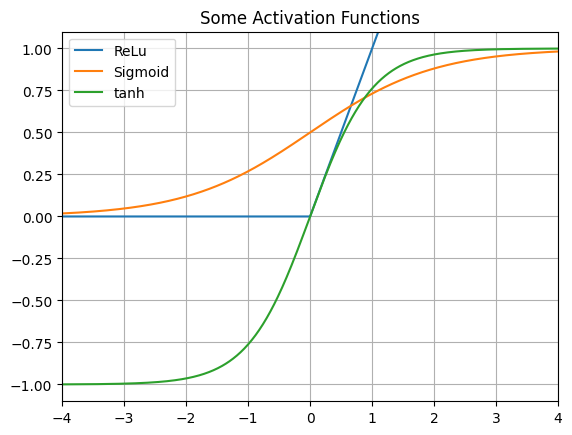

In [ ]:

x = np.arange(-4,4,.01)
plt.figure()
plt.plot(x, np.maximum(x,0), label='ReLu')
plt.plot(x, 1/(1+np.exp(-x)), label='Sigmoid')
plt.plot(x, np.tanh(x), label='tanh')
plt.axis([-4, 4, -1.1, 1.1])
plt.title('Some Activation Functions')
plt.grid(True)
l = plt.legend()
plt.show()

# Delete temporary variables, so not to cause any confusion later :-)
del x, l

In this particular exercise we will use the sigmoid function. So let's define $f(\cdot)$ as the sigmoid function

$$\sigma(x)=\frac{1}{1+\exp^{-x}}$$

In [ ]:
def sigma(x):
    # Sigmoid function
    return 1 / ( 1 + np.exp(-x) )

### Weight initialization

Now we have to initialise the weights. Let's initialize them randomly, so that their mean is zero. The weights matrix maps the input space into the output space, therefore in our case $\mathbf{W} \in \mathbb{R}^{3 \times 1}$

In [ ]:
# fix random seed for reproducibility
np.random.seed([42])

# initialize weights randomly with zero mean and uniformly distributed values in [-1,1]
W = 2 * np.random.random((3,1)) - 1

print('W =', W)

W = [[ 0.2788536 ]
 [-0.94997849]
 [-0.44994136]]


### Forward propagation

Next, let's try to implement one round of forward propagation.  This means taking an input sample and moving it forward through the network, calculating the output of the network eventually.

For our single neuron this is simply $\hat{\mathbf{y}} = \sigma(\mathbf{W}^T \mathbf{x})$, where $\mathbf{x}$ is one input vector.

Each input sample is arranged as a row of the matrix `X`, therefore we can access the first row by `X[0]`. Let's store it in the variable `X0` for easier access. We'll use `reshape` to make sure it's expressed as a column vector.

In [ ]:
x0 = np.reshape(X[0], (3,1))
print("x0 =", x0)

x0 = [[1]
 [1]
 [0]]


The output $\hat{y}$ for the first input can be calculated according to the formula given above

In [ ]:
y_out = sigma(np.dot(W.T, x0))

print('y_out =', y_out)

y_out = [[0.338245]]


the target result is stored in `y[0]`.  If you check back, you can see we defined it to be $y_0=0$. You can see that our network is pretty far away from the right answer... this is why we need to backpropagate the error, to adjust the weights in the right direction!

### Backpropagation

The following step updates the weights by propagating the error backwards through the network.  
How this is done depends on the activation function and its derivative. The activation
function used in this model is the sigmoid:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

whose derivative is

$$
\sigma'(z) = \sigma(z)\big(1 - \sigma(z)\big).
$$

The model predicts

$$
\hat{y} = \sigma(w^T x).
$$

We use the squared error loss

$$
L = \frac{1}{2}(y - \hat{y})^2 .
$$

To update the weights we compute the gradient of the loss with respect to the weights.
Using the **chain rule**, we obtain

$$
\frac{\partial L}{\partial w}
=
\frac{\partial L}{\partial \hat{y}}
\cdot
\frac{\partial \hat{y}}{\partial z}
\cdot
\frac{\partial z}{\partial w},
$$

where \(z = w^T x\).

Each term is computed as follows:

- **Error term**

$$
\frac{\partial L}{\partial \hat{y}} = \hat{y} - y
$$

- **Derivative of the sigmoid**

$$
\frac{\partial \hat{y}}{\partial z} = \hat{y}(1-\hat{y})
$$

- **Derivative of the linear input**

$$
\frac{\partial z}{\partial w} = x
$$

Combining these terms gives

$$
\frac{\partial L}{\partial w}
=
(\hat{y} - y)\,\hat{y}(1-\hat{y})\,x.
$$

The quantity

$$
\delta = (\hat{y} - y)\,\hat{y}(1-\hat{y})
$$

is the **gradient term** (called `grad` in the code).

Finally, the weight update is

$$
\Delta W = -\epsilon \, \delta \, x,
$$

where $\epsilon$ is the learning rate and $x$ denotes the input vector.

In [ ]:
# the learning rate determines the step size in the gradient descent, you can experiment with different values if you want
learning_rate = 0.5

# compute the gradient term
grad = (y_out - y[0]) * y_out * (1 - y_out)

# Calculate the weight update
W_delta = - learning_rate * grad * x0

print("W_delta = ", W_delta)

# Update the weights
W += W_delta
print("Updated weights W = ", W)

W_delta =  [[0.07406207]
 [0.07406207]
 [0.        ]]
Updated weights W =  [[ 0.35291567]
 [-0.87591642]
 [-0.44994136]]


Let's try a forward propagation again with the same input.

In [ ]:
print("y_out_old = ", y_out) # let's print the values before the update
y_out = sigma(np.dot(W.T, x0))

print('y_out =', y_out)
print('y[0] =', y[0])

y_out_old =  [[0.338245]]
y_out = [[0.37215083]]
y[0] = [1]


You should notice that the result has moved (slightly!) towards the correct answer. In order to converge to the right value we have to perform more iterations!

<a id="Q1.2:-Train-the-Perceptron"></a>
## Q1.2: Train the Perceptron [TO COMPLETE]

Let's define a complete training procedure for our model. In each iteration we have to perform the forward propagation, then we'll check how much the output differs from the target and propagate the error back (backward propagation). We'll do this for all samples and repeat the process for multiple iterations.

In [ ]:
# For the training we need to iterate over the dataset several times
num_iters = 1000

# We'll also store the mean square error (MSE) in every round so we can see how it evolves
# mse is just an array to store these values at each round:
mse = np.zeros(num_iters)

# Looping for the iterations
for it in range(num_iters):

    # For-loop going over each sample in X
    for n in range(len(X)):
        # Extract the n_th sample and the corresponding desired output
        x_n = np.reshape(X[n], (3,1))
        # Get the correponding target value
        y_target = y[n]

        # Forward propagation of the n_th sample
        y_out = sigma(np.dot(W.T, x_n))

        # Let's keep track of the sum of squared errors
        #--------------------------------------------------------------------------
        # write your code here

        # compute squared error between y_target and y_out
        mse[it] += (y_target - y_out) **2


        # compute the gradient
        grad = -2 * (y_target - y_out) * y_out * (1 - y_out) * x_n

        # Calculate the weights update
        W_delta = -learning_rate * grad

         #--------------------------------------------------------------------------
        # Update the weights
        W += W_delta

    # Divide by the number of elements to get the mean of the squared errors
    mse[it] /= len(X)

# Now let's see the output for each input sample with the trained weights
# Using batch mode (see next section) we can do this in a single line
print("Output after training, y_out =")
y_out = sigma(np.dot(X, W))
print(y_out)
print("Target output, y =")
print(y)

Output after training, y_out =
[[0.96646286]
 [0.99850911]
 [0.041253  ]
 [0.5       ]]
Target output, y =
[[1]
 [1]
 [0]
 [0]]


/tmp/ipykernel_569/54122461.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mse[it] += (y_target - y_out) **2


In [ ]:
# -----------------------
# correctness check
# -----------------------
assert mse.shape == (num_iters,)
assert np.isfinite(mse).all()
assert W.shape == (3, 1)
print('Q1.2 is correct.')

Q1.2 is correct.


<a id="Q1.3:-Plot-the-Training-Error"></a>
## Q1.3: Plot the Training Error
It is interesting to investigate the trend of the error through the training. In the next cell, plot the mean squared error over the iterations.

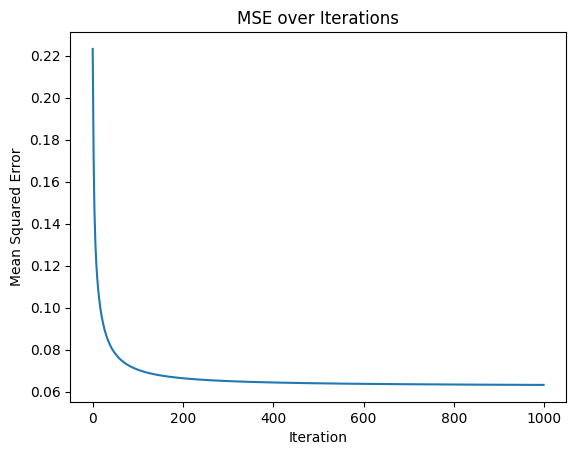

In [ ]:
plt.plot(mse)
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error")
plt.title("MSE over Iterations")
plt.show()


You should see the error going down pretty quickly in the beginning and then slowing down.

<a id="Q2:-Multi-Layer-Perceptron-(MLP)"></a>
# Q2: Multi-Layer Perceptron (MLP)

Let's consider the following training set:

||Input||         Output|
|:----:|:---:|:---:|---:|
| $x_1$|$x_2$|$x_3$| $y$|
| 0    | 0   | 0   | 1  |
| 0    | 0   | 1   | 1  |
| 0    | 1   | 0   | 1  |
| 0    | 1   | 1   | 0  |
| 1    | 0   | 0   | 1  |
| 1    | 0   | 1   | 0  |
| 1    | 1   | 0   | 1  |
| 1    | 1   | 1   | 1  |

In particular, the new input-output configuration represents the following relation between three input vector components:
$$
y = \text{NOT}((x_0 \: \text{XOR} \: x_1) \: \text{AND} \: x_2)
$$

Where $x_0$, $x_1$ and $x_2$ correspond the input vector components, and $\text{NOT}$, $\text{XOR}$ and $\text{AND}$ stands for the corresponding logical operations.

As an example, coinsider the first sample (row), $x_0 \: \text{XOR} \: x_1$ is $0$ and the $\text{AND}$ operation between it and $x_3$ is again $0$. The negation of $0$ is $1$, which indeed has been reported as the target value for this sample.


This problem is interesting because it can not be solved by using a single-layer perceptron. Indeed, you will need (at least) a two-layer network to solve it. So,  we will first show that a one-layer Neural Network can not solve this task, then we will define a two-layer Neural Network able to compute the correct solution.

In [ ]:
# -----------------------
# DO NOT MODIFY THIS CELL
# -----------------------

np.random.seed(42)

X = np.array([
    [0, 0, 0],
    [0, 0, 1],
    [0, 1, 0],
    [0, 1, 1],
    [1, 0, 0],
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1]
])

y = np.array([[1, 1, 1, 0, 1, 0, 1, 1]]).T

### A Single-Layer Perceptron

The following code trains a **single-layer network** with a sigmoid activation. Run it and observe the final outputs and the difference from the target values. This part is provided to show that a one-layer model is not sufficient for this task.


Let's initialize the weights and define the activation function.

In [ ]:
# -----------------------
# provided example
# -----------------------
W = 2 * np.random.random((3, 1)) - 1


def sigma(x):
    return 1 / (1 + np.exp(-x))

### Gradient Calculation (Backpropagation)

In this exercise the model is

$$
y_{out} = \sigma(w^T x)
$$

where

$$
\sigma(z) = \frac{1}{1 + e^{-z}}.
$$

The loss for one observation is

$$
L = \frac{1}{2}(y_{out} - y)^2.
$$

To update the weights we compute the gradient of the loss with respect to the weights \(w\).  
Because the loss depends on \(w\) **through the sigmoid activation**, we apply the **chain rule**.

Let

$$
z = w^T x.
$$

Then the model becomes

$$
y_{out} = \sigma(z).
$$

Using the chain rule,

$$
\frac{\partial L}{\partial w}
=
\frac{\partial L}{\partial y_{out}}
\cdot
\frac{\partial y_{out}}{\partial z}
\cdot
\frac{\partial z}{\partial w}.
$$

Now compute each term:

**1. Derivative of the squared error**

$$
\frac{\partial L}{\partial y_{out}} = y_{out} - y
$$

**2. Derivative of the sigmoid**

$$
\frac{\partial y_{out}}{\partial z} = y_{out}(1-y_{out})
$$

**3. Derivative of the linear function**

$$
\frac{\partial z}{\partial w} = x
$$

Multiplying the three terms gives

$$
\frac{\partial L}{\partial w}
=
(y_{out}-y)\; y_{out}(1-y_{out})\; x.
$$


Therefore the gradient used in the code is

```python
grad = (y_out - y_target) * y_out * (1 - y_out)


Now, let's run the network below to check whether it is able to solve the XOR problem.

In [ ]:
num_iters = 10000
learning_rate = 0.5

for it in range(num_iters):
    for n in range(len(X)):
        x_n = np.reshape(X[n], (3, 1))
        y_target = y[n]

        # Forward propagation
        y_out = sigma(np.dot(W.T, x_n))

        # Compute the Gradient
        grad = (y_out - y_target) * y_out * (1 - y_out)

         # Calculate the weights update
        W_delta = -learning_rate * grad * x_n

        # Update the weights
        W += W_delta


# Now let's see the output for each input sample with the trained weights
# Using batch mode we can do this in a single line
y_out = sigma(np.dot(X, W))
print("Output after training, y_out =")
print(y_out)
print("Desired output, y = ")
print(y)
print("Difference = ", np.linalg.norm(y-y_out))

Output after training, y_out =
[[5.00000000e-01]
 [1.87066709e-05]
 [9.99254905e-01]
 [2.44741709e-02]
 [9.99255174e-01]
 [2.44828012e-02]
 [9.99999444e-01]
 [9.71146791e-01]]
Desired output, y = 
[[1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]]
Difference =  1.1189256441752768


**Written question.** Based on the output above, explain briefly why the single-layer model fails on this problem. [TO COMPLETE]

**Write your answer below.**

Single layer perceptron can only create a linear decision boundary whereas the problem requires a non linear decision boundary which only a network with hidden layers can represent

<a id="Q2.1:-Train-the-Two-Layer-Network"></a>
## Q2.1: Train the Two-Layer Network [TO COMPLETE]

Now build a **two-layer neural network** with one hidden layer containing `4` hidden nodes.

Use the notation

$$
h = \sigma(W_1^T x), \qquad \hat y = \sigma(W_2^T h),
$$

where

$$
W_1 \in \mathbb{R}^{3 \times 4}, \qquad W_2 \in \mathbb{R}^{4 \times 1}.
$$

In the previous part (one-layer network), the gradient of the loss with respect to the weights depended directly on the input \(x\).  
In this two-layer network, the output depends on the weights through **two transformations**:

$$
x \rightarrow h \rightarrow \hat y.
$$

Therefore, when computing the gradients we must apply the **chain rule** multiple times.  


The steps are conceptually:

1. **Forward pass**
   - Compute the hidden layer output  
   $$
   h = \sigma(W_1^T x)
   $$
   - Compute the final prediction  
   $$
   \hat y = \sigma(W_2^T h)
   $$

2. **Compute the output error**

$$
(\hat y - y)
$$

3. **Update the output-layer weights \(W_2\)**  
The gradient has the same form as in the one-layer case, but now the input is \(h\):

$$
\frac{\partial L}{\partial W_2}
=
(\hat y - y)\,\hat y(1-\hat y)\,h
$$

4. **Update the hidden-layer weights \(W_1\)**  
The error must first pass through the output layer before affecting the hidden layer.  
Applying the chain rule gives

$$
\frac{\partial L}{\partial W_1}
=
(\hat y - y)\,\hat y(1-\hat y)\,W_2\,h(1-h)\,x
$$

This backward propagation of gradients from the output layer to earlier layers is what is known as **backpropagation**.

Let's initialize the weights randomly again.


In [ ]:
# -----------------------
# DO NOT MODIFY THIS CELL
# -----------------------
np.random.seed(42)
num_hidden = 4
W_1 = 2 * np.random.random((3, num_hidden)) - 1
W_2 = 2 * np.random.random((num_hidden, 1)) - 1

Complete the missing parts of the code by implementing:

- the **forward pass** for the hidden layer `h`
- the **forward pass** for the network output `y_out`
- the **squared error accumulation** in `mse`
- the **final network output computation**

The backpropagation and weight updates are already provided.

In [ ]:
# -----------------------
# write your code here
# -----------------------
num_iters = 2000
learning_rate = 0.5

mse = np.zeros(num_iters)
num_input = len(X[0])

for it in range(num_iters):
    for n in range(len(X)):
        x_n = np.reshape(X[n], (3, 1))
        y_target = y[n]

        ## Forward propagation
        # Calculate hidden layer
        h = sigma(np.dot(W_1.T, x_n))

        # Calculate network output
        y_out = sigma(np.dot(W_2.T, h))

        # Keep track of the squared error
        # Use the squared error: (y_target - y_out)^2
        mse[it] += (y_target - y_out[0,0])**2

        # ----------------------------
        # Backpropagation (given)
        # ----------------------------
        grad = (y_out - y_target) * y_out * (1 - y_out)

        W_1_update = np.zeros((num_input, num_hidden))
        for i in range(num_hidden):
            for k in range(num_input):
                W_1_update[k, i] = grad * W_2[i] * h[i] * (1 - h[i]) * x_n[k]

        # Update the weights
        W_1 += -learning_rate * W_1_update
        W_2 += -learning_rate * grad * h.reshape((num_hidden, 1))

    # Compute mean squared error for this iteration
    mse[it] /= len(X)

# Compute final output
h = sigma(np.dot(X, W_1))
y_out = sigma(np.dot(h, W_2))

print("Output after training, y_out =")
print(y_out)
print("Desired output, y =")
print(y)
print("Difference = ", np.linalg.norm(y - y_out))

/tmp/ipykernel_569/906947798.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mse[it] += (y_target - y_out[0,0])**2
/tmp/ipykernel_569/906947798.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  W_1_update[k, i] = grad * W_2[i] * h[i] * (1 - h[i]) * x_n[k]


Output after training, y_out =
[[0.99705046]
 [0.98526935]
 [0.99355122]
 [0.01529916]
 [0.99563973]
 [0.01704398]
 [0.99413338]
 [0.98480834]]
Desired output, y =
[[1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]]
Difference =  0.03280329408418712


In [ ]:
# -----------------------
# correctness check
# -----------------------
assert mse.shape == (num_iters,)
assert np.isfinite(mse).all()
assert np.linalg.norm(y - y_out) < 0.1
print('Q2.1 seems correct.')

Q2.1 seems correct.


<a id="Q2.2:-Plot-the-Training-Error"></a>
## Q2.2: Plot the Training Error

Using the vector `mse` computed during training, plot the **mean squared error (MSE)** as a function of the iteration number.

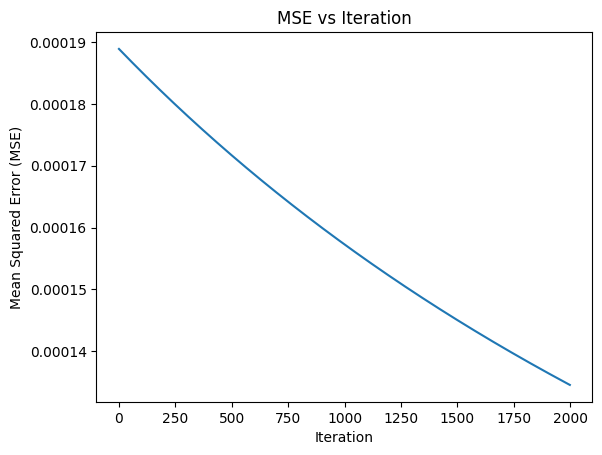

In [ ]:
# -----------------------
plt.plot(mse)
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("MSE vs Iteration")
plt.show()
# -----------------------


You should observe that the MSE is decreasing.

<a id="Q3:-Handwritten-Digits-Classification"></a>
# Q3: Handwritten Digits Classification

In this exercise, we try to apply what we learned in the previous exercise in a real-world scenario. In particular, we consider a simple digits classification problem. The model turns out to be similar to the perceptron, but here we will use the softmax activation function and cross-entropy loss function. The idea is to create a model that has as input an image of a handwritten digit, and that returns a vector of 10 probabilities (one for each possible digit $0-9$).

### Dataset
The dataset that we will use in this exercise is included in [scikit-learn](https://scikit-learn.org/stable/), one of the major Machine Learning libraries. The dataset is called `load_digits` and contains several hundreds of samples. Each datapoint is made of the handwritten digit image (or rather its $8\times8$ pixel representation), that will be the input of our model, and the target digit value.

Let's start by plotting one of this handwritten digit:

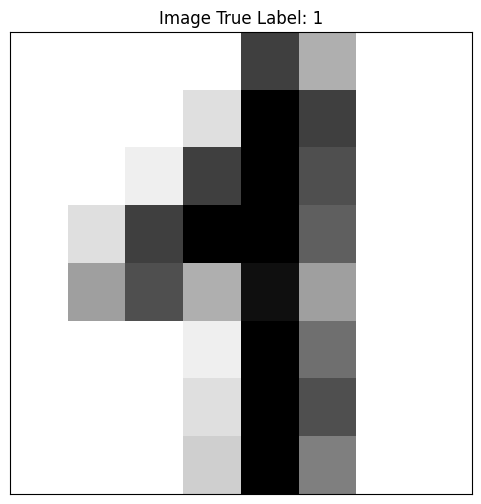

In [ ]:

np.random.seed([42])

digits = load_digits()

def plot_digit(x, y):
  plt.figure(figsize=(6, 6))
  plt.imshow(x, cmap=plt.cm.gray_r,
            interpolation='nearest')
  plt.title("Image True Label: %d" % y)
  plt.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
  plt.show()

sample_index = 42
plot_digit(digits.images[sample_index], digits.target[sample_index])

It is better to check how an input in the dataset $\mathbf{X}$ and its related target $\mathbf{y}$ are represented in the dataset:

In [ ]:
data = np.asarray(digits.images[sample_index], dtype='float32')
target = np.asarray(digits.target[sample_index], dtype='int32')

np.set_printoptions(threshold=np.inf) # In this way we print the full array
print("X:", data)
print("y:", target)

X: [[ 0.  0.  0.  0. 12.  5.  0.  0.]
 [ 0.  0.  0.  2. 16. 12.  0.  0.]
 [ 0.  0.  1. 12. 16. 11.  0.  0.]
 [ 0.  2. 12. 16. 16. 10.  0.  0.]
 [ 0.  6. 11.  5. 15.  6.  0.  0.]
 [ 0.  0.  0.  1. 16.  9.  0.  0.]
 [ 0.  0.  0.  2. 16. 11.  0.  0.]
 [ 0.  0.  0.  3. 16.  8.  0.  0.]]
y: 1


In [ ]:
# the dataset is the flattened version of all the images ( 8 x 8 = 64 values for 1797 images)
print(digits.data.shape)

(1797, 64)


So essentialy the dataset is a matrix with the (color) values for each pixel and for each image, whereas the target is the digit itself.

#### One-hot encoding
In order to have a representation of the target that will be similar to the output of the model (i.e. $\hat{y}=0$ or $1$ for each of the 10 digits), we will use one-hot encoding. Basically, the one-hot encoding allow us to encode a categorical integer feature using a one-of-K scheme, where each class is translated to a specific index of an array.

In [ ]:
def one_hot(n_classes, y):
    return np.eye(n_classes)[y]

For example, if there are 10 classes in total and a sample belongs to class number 3, we can translate the output to the following lenght-ten array of 0 and 1 (class 3 is in the fourth index because we start counting from zero!):

In [ ]:
one_hot(n_classes=10, y=3)

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])


<a id="Q3.1:-Implement-the-Softmax-Function"></a>
## Q3.1: Implement the Softmax Function [TO COMPLETE]

As activation function we will use the Softmax function. This function is useful for multiclass classification with one-hot targets because it converts logits (pre-activations) into $m$ probabilities that sum to one:
$$
\mathrm{softmax}(\mathbf{x})_j = \frac{e^{x_j}}{\sum_{i=1}^{m} e^{x_i}}.
$$

Implement `softmax(x)` so that:
- it returns a vector of probabilities with the same shape as `x`,
- all returned entries are nonnegative,
- the entries sum to 1,
- it is numerically stable (subtracting `np.max(x)` before exponentiating is recommended).


In [61]:

# -----------------------
# write your code here
def softmax(x):
    x_shift = x - np.max(x)
    exp_x = np.exp(x_shift)
    return exp_x / np.sum(exp_x)
    # -----------------------

In [ ]:
# -----------------------
# correctness check
# -----------------------
probs = softmax(np.array([1.0, 2.0, 3.0]))
assert np.allclose(np.sum(probs), 1.0)
assert np.all(probs >= 0)
print('Q3.1 is correct.')

Q3.1 is correct.


### Loss Function: Cross Entropy ###
Usually, a neural network classifier that use the softmax function in the final layer is trained using Cross-Entropy as loss function:
$$H(Y,P)=-E_{y \sim Y}[log \;P(y)]$$
where $Y$ and $P$ are the true and predicted labels distributions.

In [ ]:
EPSILON = 1e-8 # this is needed for numerical stability

def cross_entropy(Y_true, Y_pred):
    Y_true, Y_pred = np.atleast_2d(Y_true), np.atleast_2d(Y_pred) # make sure the dimensions are right
    loglikelihoods = np.sum(np.log(EPSILON + Y_pred) * Y_true, axis=1)
    return -np.mean(loglikelihoods)

### Weights Initailiazation

Similarly to what we did in previous exercises, we have to initialize the weights but in this case we will consider the bias term as well. Therefore we define the weights $\mathbf{W}\in\mathbb{R}^{m \times n}$ and the bias $\mathbf{b}\in\mathbb{R}^m$, where $n$ is the input size and $m$ is the number of classes.
Now we can define the output of our model as

$$\hat{\mathbf{y}}=softmax(\textbf{W} \textbf{x}+\mathbf{b})$$



In [ ]:
np.random.seed([42])

input_size = digits.data.shape[1]
n_classes = len(np.unique(digits.target))

W = np.random.uniform(size=(input_size,n_classes), high=0.1, low=-0.1)
b = np.random.uniform(size=n_classes, high=0.1, low=-0.1)

Let's consider a sample from the training set, and plot the current output of our model before training it.

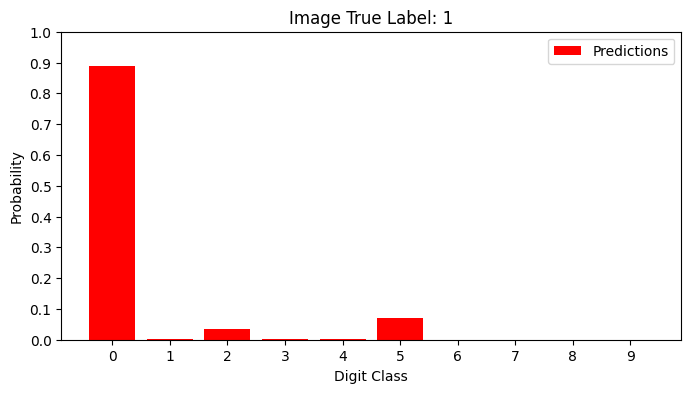

In [ ]:
# Plot function
def plot_predictions(y_out, true_label):
    plt.figure(figsize=(8, 4))
    plt.bar(range(n_classes), y_out, label="Predictions", color="red")
    plt.ylim(0, 1)
    plt.yticks(np.arange(0, 1.1, 0.1))
    plt.xticks(range(n_classes))
    plt.legend()
    plt.ylabel("Probability")
    plt.xlabel("Digit Class")
    plt.title("Image True Label: %d" % true_label)
    plt.show()

# Compute prediction probabilities
y_out = softmax(np.dot(digits.data[sample_index], W) + b)

# Plot predictions
plot_predictions(y_out, digits.target[sample_index])

We see that the most likely predictions for our _untrained_ model is just $0$ (or it could have been any other random guess) for the handwritten $1$.


<a id="Q3.2:-Train-the-Multiclass-Classifier"></a>
## Q3.2: Train the Multiclass Classifier [TO COMPLETE]

As in the previous exercise, define a training procedure. In this case, you will train the multiclass classifier using the softmax activation and the cross-entropy loss.

You may use the standard result that for **softmax + cross-entropy**, the gradient with respect to the logits is:
$$
\nabla_z L = \hat{y} - y.
$$

Your implementation should:
- compute the logits $z = xW + b$,
- convert logits to probabilities using `softmax`,
- use the gradient above to compute parameter updates,
- update both `W` and `b`,
- store the loss and accuracy during training.

Follow the variable names and initialization already provided in the notebook.


In [ ]:
num_iters = 30
learning_rate = 0.0005

for it in range(num_iters):
    iteration_accuracy = []
    iteration_loss = []
    for i, (X, y) in enumerate(zip(digits.data, digits.target)):

        # implement forward propagation
        y_out = softmax(np.dot(X, W) + b)

        # compute the error
        y_true = one_hot(n_classes, y)
        error = y_out - y_true

        # compute the gradient
        grad_W = np.outer(X, error)
        grad_b = error

        # update the weights
        W -= learning_rate * grad_W
        b -= learning_rate * grad_b

        iteration_accuracy.append(np.argmax(y_out) == y)
        iteration_loss.append(cross_entropy(one_hot(n_classes,y), y_out))

    print(f"iteration: {it}, -- accuracy: {np.mean(np.asarray(iteration_accuracy)):.2%}, -- loss: {np.mean(iteration_loss):.4f}")

iteration: 0, -- accuracy: 82.92%, -- loss: 0.5599
iteration: 1, -- accuracy: 95.05%, -- loss: 0.1789
iteration: 2, -- accuracy: 96.61%, -- loss: 0.1373
iteration: 3, -- accuracy: 96.99%, -- loss: 0.1166
iteration: 4, -- accuracy: 97.27%, -- loss: 0.1031
iteration: 5, -- accuracy: 97.55%, -- loss: 0.0932
iteration: 6, -- accuracy: 97.66%, -- loss: 0.0856
iteration: 7, -- accuracy: 97.83%, -- loss: 0.0793
iteration: 8, -- accuracy: 97.89%, -- loss: 0.0741
iteration: 9, -- accuracy: 98.16%, -- loss: 0.0697
iteration: 10, -- accuracy: 98.33%, -- loss: 0.0659
iteration: 11, -- accuracy: 98.44%, -- loss: 0.0626
iteration: 12, -- accuracy: 98.61%, -- loss: 0.0596
iteration: 13, -- accuracy: 98.78%, -- loss: 0.0570
iteration: 14, -- accuracy: 98.89%, -- loss: 0.0547
iteration: 15, -- accuracy: 98.94%, -- loss: 0.0526
iteration: 16, -- accuracy: 98.94%, -- loss: 0.0506
iteration: 17, -- accuracy: 99.00%, -- loss: 0.0489
iteration: 18, -- accuracy: 99.00%, -- loss: 0.0473
iteration: 19, -- accu

As you can see during the training the accuracy increases after each iteration, while the loss function value progressively declines.

Finally, let's check how the prediction capability of our model changes after the training:

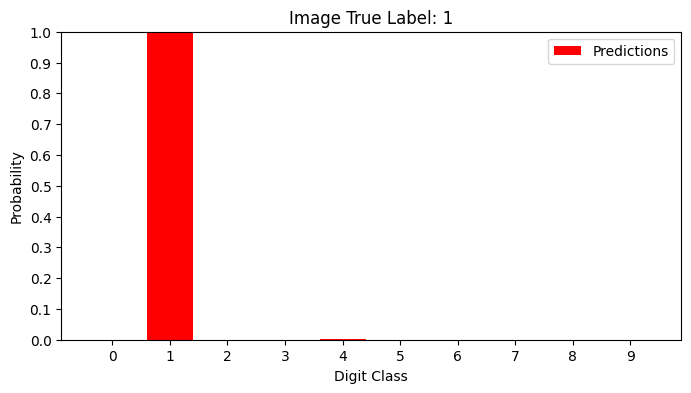

In [ ]:
y_out = softmax(np.dot(digits.data[sample_index], W) + b)
plot_predictions(y_out, digits.target[sample_index])

Now, let's test our model on custom generated images whose size are $8 \times 8$. As you can see, we can simply simulate the number drawing by considering some non-zero pixels among zero-valued pixels. For example, the following test case includes `number 2` inside, that can be seen from positions of non-zero pixel locations as well.

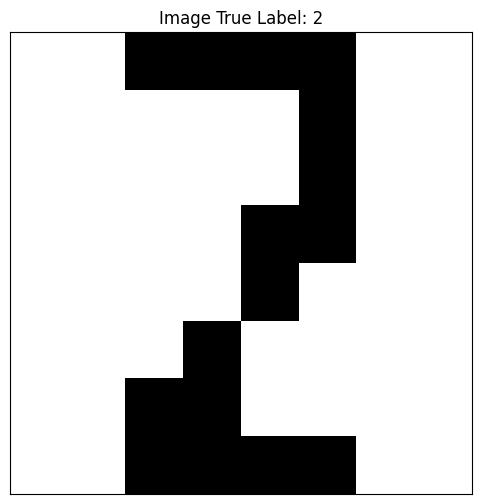

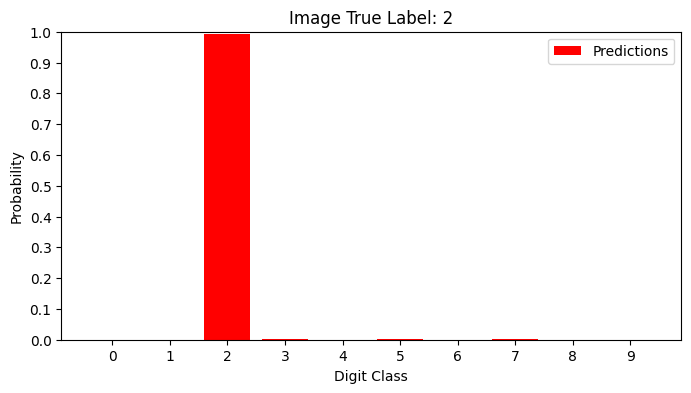

In [ ]:
test_num = 2
px = 10
test_img = np.array([
                    [0.,  0.,  px,  px, px,  px,  0.,  0.],
                    [0.,  0.,  0.,  0., 0.,  px,  0.,  0.],
                    [0.,  0.,  0.,  0., 0.,  px,  0.,  0.],
                    [0.,  0.,  0.,  0., px,  px,  0.,  0.],
                    [0.,  0.,  0.,  0., px,  0.,  0.,  0.],
                    [0.,  0.,  0.,  px, 0.,  0.,  0.,  0.],
                    [0.,  0.,  px,  px, 0.,  0.,  0.,  0.],
                    [0.,  0.,  px,  px, px,  px,  0.,  0.]
])
plot_digit(test_img, test_num)

test_img = test_img.flatten() # flatten the array to length (64, )
y_pred = softmax(np.dot(test_img, W) + b)
plot_predictions(y_pred, test_num)

<a id="Q4:-Regularized-Logistic-Regression"></a>
# Q4: Regularized Logistic Regression

In this question, you will implement **L2-regularized logistic regression**.

In particular, you will implement:

- the sigmoid function
- the regularized logistic loss
- the gradient formulas
- the training procedures for Batch Gradient Descent and Mini-batch SGD

Throughout this question, use the notation

$$
p_i = \sigma(w^T x_i + b),
$$

where

$$
\sigma(z) = \frac{1}{1 + e^{-z}}.
$$

The regularized logistic loss function is similar to the standard logistic regression loss function, but it includes an additional regularization term:

$$
L = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i \log(p_i) + (1-y_i)\log(1-p_i)\right] + \frac{\lambda}{2n}\sum_{j=1}^{p} w_j^2.
$$

Only the weight vector $w$ is regularized. The bias term $b$ is **not** regularized.

In [55]:
# -----------------------
# DO NOT MODIFY THIS CELL
# -----------------------
np.random.seed(42)

X_data, y_data = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)

n_train = len(y_train)
print(X_train.shape, X_test.shape)

(800, 2) (200, 2)


<a id="Q4.1:-Batch-Gradient-Descent"></a>
## Q4.1: Batch Gradient Descent [TO COMPLETE]

Implement **L2-regularized logistic regression** using **Batch Gradient Descent**.

Use the update rules

$$
w \leftarrow w - \eta \left[\frac{1}{n}X^T(p-y) + \frac{\lambda}{n}w\right]
$$

and

$$
b \leftarrow b - \eta \left(\frac{1}{n}\sum_{i=1}^{n}(p_i-y_i)\right).
$$

**Tasks:**

1. Write a function `sigmoid(z)`.
2. Write a function `compute_loss(X, y, w, b, lam)`.
3. Write a function `compute_gradients_batch(X, y, w, b, lam)`.
4. Train the model for **300 iterations** using:
   - `np.random.seed(42)`
   - `lr = 0.1`
   - `lam = 0.1`
5. Compute:
   - `losses_batch`
   - `batch_final_loss`
   - `batch_test_acc`

In [56]:
# -----------------------
# write your code here
# -----------------------

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def compute_loss(X, y, w, b, lam):
    n = X.shape[0]
    z = X.dot(w) + b
    p = sigmoid(z)

    data_loss = -(1/n) * np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
    reg_loss = (lam / (2 * n)) * np.sum(w ** 2)

    return data_loss + reg_loss


def compute_gradients_batch(X, y, w, b, lam):
    n = X.shape[0]
    z = X.dot(w) + b
    p = sigmoid(z)

    dw = (1/n) * (X.T @ (p-y)) + (lam/n) * w
    db = (1 / n) * np.sum(p - y)
    return dw, db


np.random.seed(42)
w_batch = np.random.randn(X_train.shape[1])
b_batch = 0.0

lr = 0.1
lam = 0.1
losses_batch = []

for i in range(300):
    loss = compute_loss(X_train, y_train, w_batch, b_batch, lam)
    losses_batch.append(loss)

    dw, db = compute_gradients_batch(X_train, y_train, w_batch, b_batch, lam)

    w_batch = w_batch - lr * dw
    b_batch = b_batch - lr * db

batch_final_loss = compute_loss(X_train, y_train, w_batch, b_batch, lam)
yhat_batch = (sigmoid(X_test.dot(w_batch) + b_batch) >= 0.5).astype(int)
batch_test_acc = np.mean(yhat_batch == y_test)

print(batch_final_loss)
print(batch_test_acc)

0.09816204295501157
0.96


In [57]:
# -----------------------
# correctness check
# -----------------------
assert np.isfinite(batch_final_loss)
assert batch_final_loss < 0.1
assert batch_test_acc >= 0.95
print('Q4.1 seems correct.')

Q4.1 seems correct.


<a id="Q4.2:-Mini-batch-SGD"></a>
## Q4.2: Mini-batch SGD [TO COMPLETE]
Now implement **Mini-batch SGD** for the same regularized logistic regression model, following the same style used in class.

Use mini-batches of size `100`. For a mini-batch $(X_{\text{batch}}, y_{\text{batch}})$, compute

$$
\nabla_w = \frac{1}{m_b}X_{\text{batch}}^T(p-y) + \frac{\lambda}{n}w
$$

and

$$
\nabla_b = \frac{1}{m_b}\sum (p-y),
$$

where $m_b$ is the mini-batch size and $n$ is the **full training sample size**.

**Tasks:**

1. Write a function `compute_gradients_sgd(X_batch, y_batch, w, b, lam, n)`.
2. Train the model for **30 epochs** using:
   - `np.random.seed(42)`
   - `lr = 0.05`
   - `lam = 0.1`
   - `batch_size = 100`
3. Shuffle the training data at the beginning of each epoch.
4. Record the mini-batch loss **after each update** in `sgd_losses`.
5. Compute:
   - `sgd_losses`
   - `sgd_final_loss`
   - `sgd_test_acc`

In [58]:
# -----------------------
# write your code here
# -----------------------

def compute_gradients_sgd(X_batch, y_batch, w, b, lam, n):
    mb = X_batch.shape[0]
    z = X_batch.dot(w) + b
    p = sigmoid(z)

    dw = (1 / mb) * (X_batch.T @ (p - y_batch)) + (lam / n) * w
    db = (1 / mb) * np.sum(p - y_batch)

    return dw, db

np.random.seed(42)
w_sgd = np.random.randn(X_train.shape[1])
b_sgd = 0.0

lr = 0.05
lam = 0.1
batch_size = 100
sgd_losses = []

for epoch in range(30):
    perm = np.random.permutation(n_train)

    for i in range(0, n_train, batch_size):
        batch_idx = perm[i:i+batch_size]
        X_batch = X_train[batch_idx]
        y_batch = y_train[batch_idx]

        dw, db = compute_gradients_sgd(X_batch, y_batch, w_sgd, b_sgd, lam, n_train)
        w_sgd = w_sgd - lr * dw
        b_sgd = b_sgd - lr * db

        loss = compute_loss(X_batch, y_batch, w_sgd, b_sgd, lam)
        sgd_losses.append(loss)

sgd_final_loss = compute_loss(X_train, y_train, w_sgd, b_sgd, lam)
yhat_sgd = (sigmoid(X_test.dot(w_sgd) + b_sgd) >= 0.5).astype(int)
sgd_test_acc = np.mean(yhat_sgd == y_test)

print(sgd_final_loss)
print(sgd_test_acc)

0.12803616078717986
0.96


In [59]:
# -----------------------
# correctness check
# -----------------------
assert sgd_losses[-1] < sgd_losses[0]
assert sgd_final_loss < 0.15
assert sgd_test_acc >= 0.95
print('Q4.2 seems correct.')

Q4.2 seems correct.


<a id="Q4.3:-Plot-the-Training-Loss-Curves"></a>
## Q4.3: Plot the Training Loss Curves [TO COMPLETE]

Plot the two training-loss curves on the same figure.

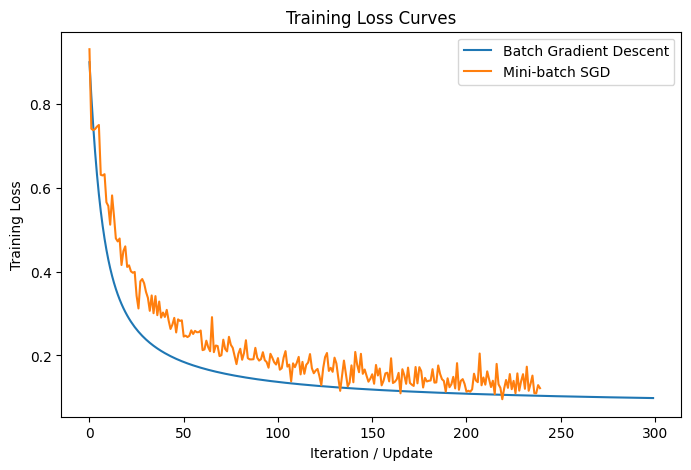

In [60]:
# -----------------------
# write your code here
# -----------------------
plt.figure(figsize=(8, 5))
plt.plot(losses_batch, label="Batch Gradient Descent")
plt.plot(sgd_losses, label="Mini-batch SGD")
plt.xlabel("Iteration / Update")
plt.ylabel("Training Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.show()


<a id="Q4.4:-Compare-Batch-GD-and-Mini-batch-SGD"></a>
## Q4.4: Compare Batch GD and Mini-batch SGD [TO COMPLETE]

Compare **Batch GD** and **Mini-batch SGD** in terms of:

1. convergence behavior,
2. computational cost.

Which method is usually preferred in practice for large datasets, and why?

**Write your answer in the next cell.**

Both methods converge to similar training loss values. Batch gradient descent shows a smooth and stable decrease in loss because each update uses the full dataset. Mini-batch SGD exhibits more noise in the loss curve because each update uses only a subset of the data, but it still trends downward toward a similar minimum.

In terms of computational cost, batch gradient descent requires computing gradients over the entire dataset for every update, which becomes expensive for large datasets. Mini-batch SGD is computationally more efficient because it uses smaller batches, allowing faster updates and better scalability.

In practice, mini-batch SGD is usually preferred for large datasets because it reduces computational cost per update and can train models much more efficiently while still achieving good convergence.

## Q5
Q5 is referenced in the assignment overview, but no corresponding question content appears in the notebook provided.
